In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.maf_proto as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import glob

from rubin_scheduler.scheduler.utils import get_current_footprint

from os.path import basename

In [2]:
def read_sql(db_file):
    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)
    return run_name, visits_array


In [3]:
nside=32
fp, labels = get_current_footprint(nside=nside)

In [4]:
db_files = glob.glob("*10yrs.db")

count_needed = 6
seeing_limit = 1.4
summary_stats = []

for filename in db_files:
    run_name, visits_array = read_sql(filename)
    arrays = []
    infos = []
    reg_visit = ["ToO" not in note and "twili" not in note for note in visits_array["scheduler_note"]]
    good_seeing = visits_array["seeingFwhmEff"] < seeing_limit

    for filtername in "ugrizy":
        
        info = {"run_name": run_name}
        sub_data = visits_array[np.where((visits_array["band"] == filtername) & (reg_visit) & (good_seeing))]
        info['observations_subset'] = "filter=%s, no ToO or twilight, seeingFwhmEff < %.1f" % (filtername, seeing_limit)
        sl = maf.Slicer(nside=nside)
        times = np.arange(3653)
        metric = maf.AccumulateCountMetric(times)
        #metric = maf.CountMetric()
        # Run the metics through the slicer
        hp_array, info = sl(sub_data, metric, info=info)
        arrays.append(hp_array)
        infos.append(info)

        year = 1
        val = hp_array[:, 365*year]
        in_fp = np.where(fp[filtername] > 0)[0]
        area_missed = np.where(val[in_fp] < count_needed)[0].size * hp.nside2pixarea(nside, degrees=True)
        summary_stats.append(maf.gen_summary_row(info, "Area Missed", area_missed))

        frac_area_missed = np.where(val[in_fp] < count_needed)[0].size / np.where(val[in_fp] > 0)[0].size
        summary_stats.append(maf.gen_summary_row(info, "Frac Area Missed", frac_area_missed))
        

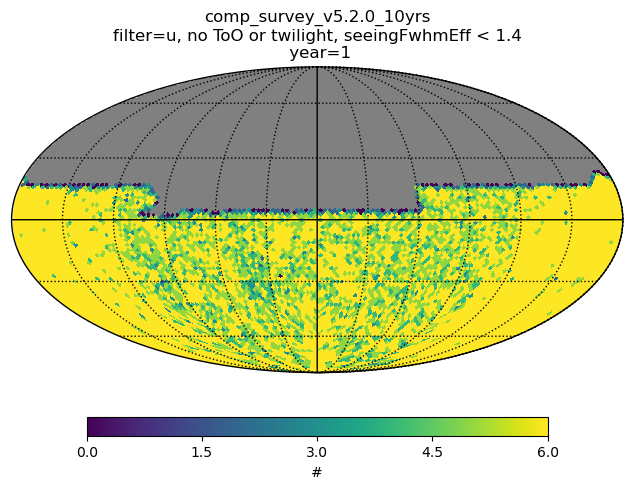

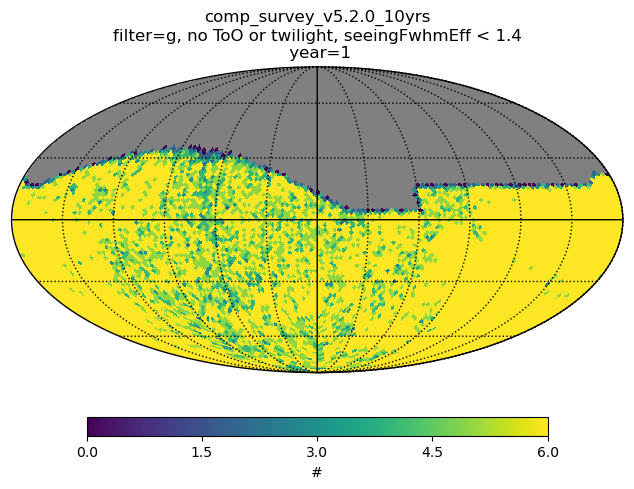

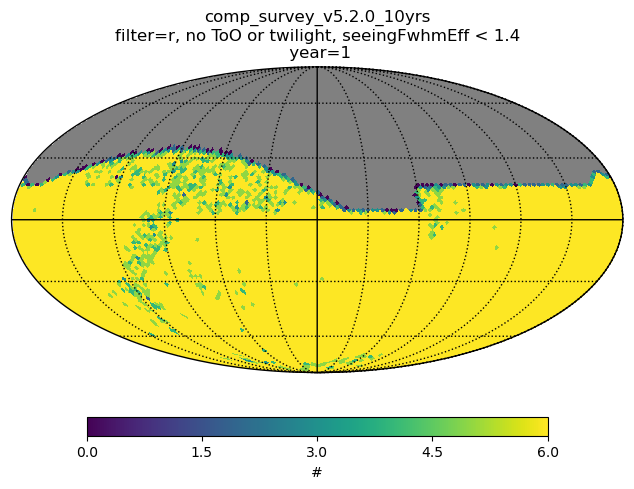

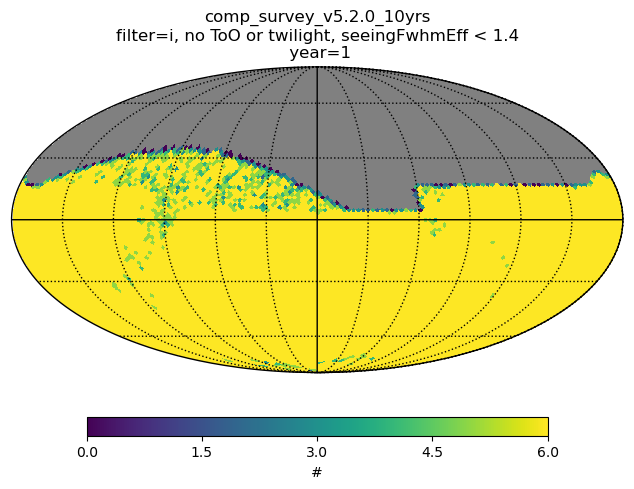

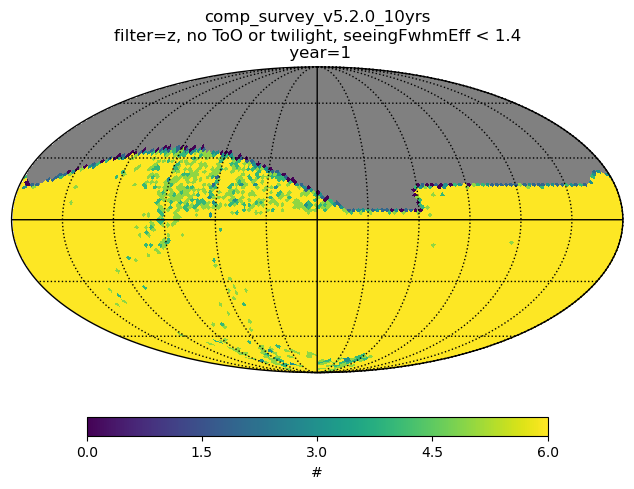

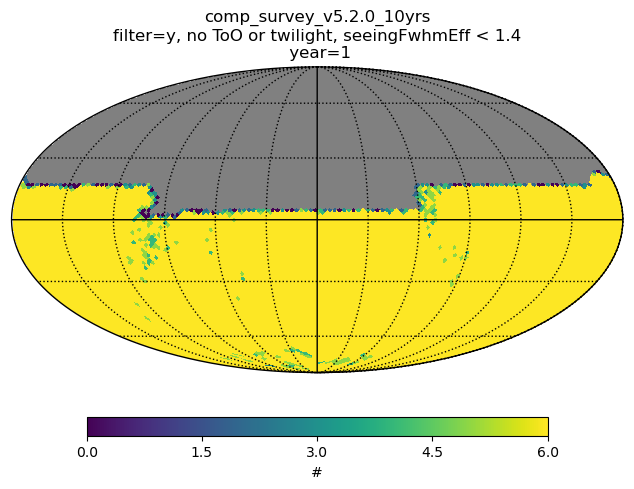

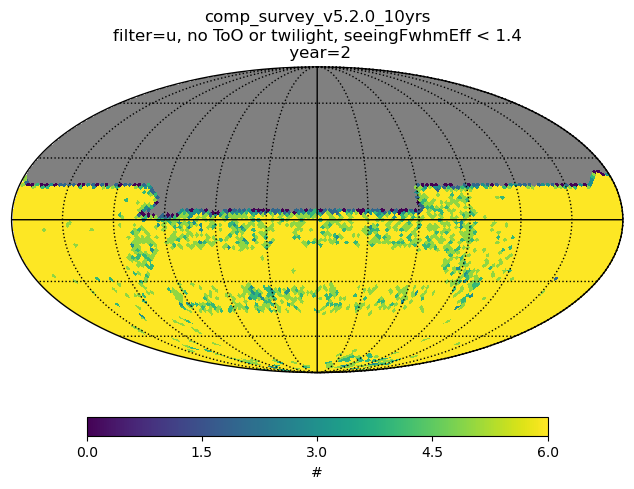

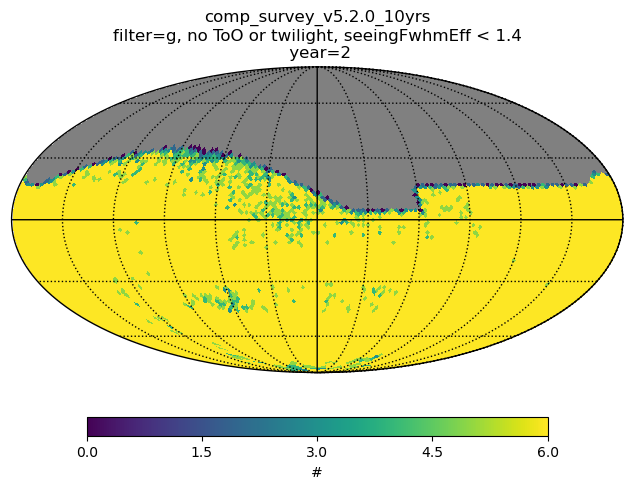

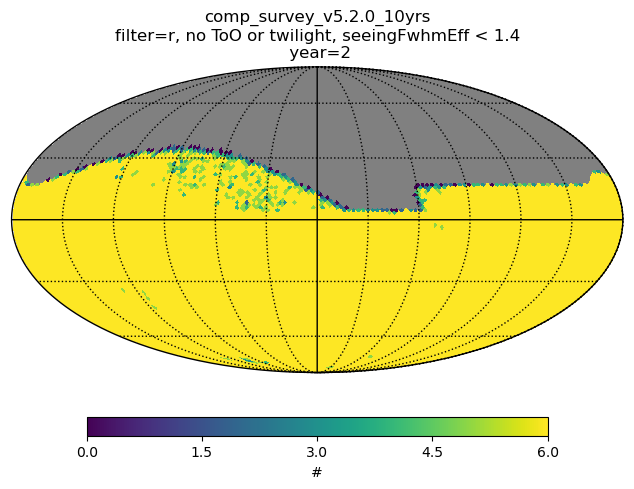

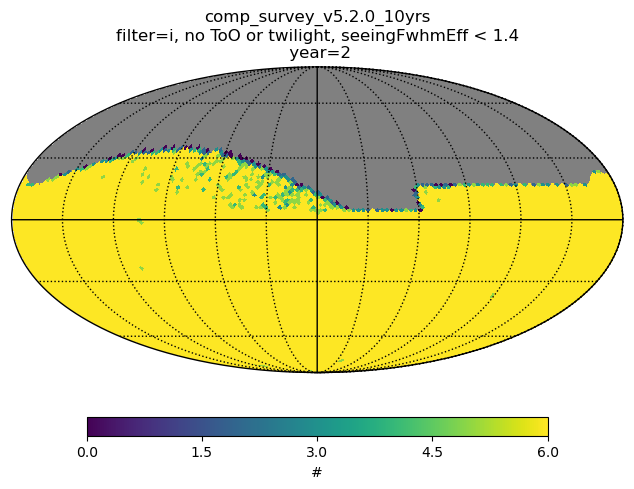

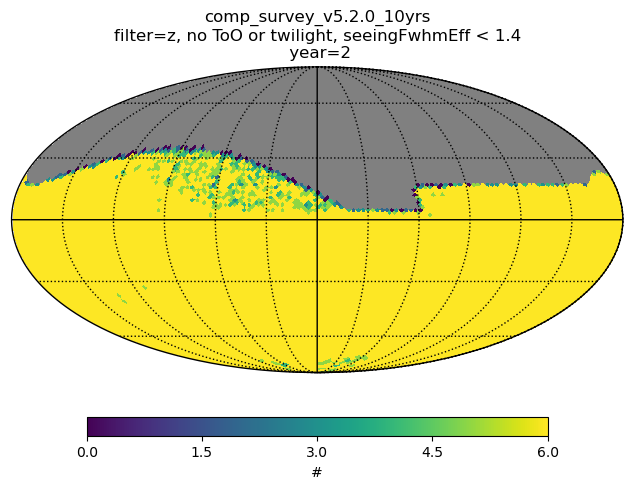

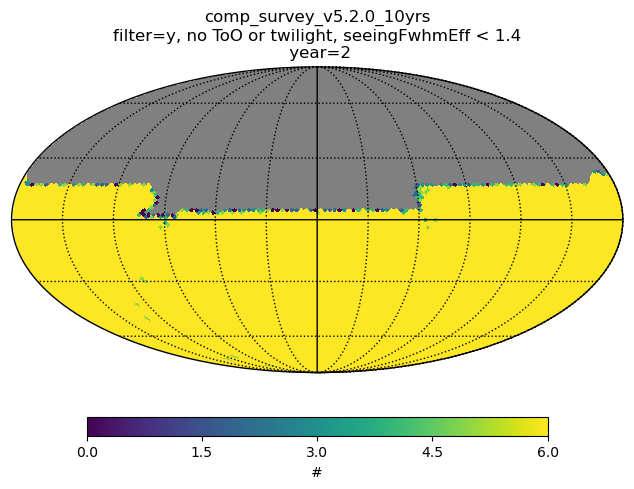

In [5]:
n_max = 6
years = [1,2]
for year in years:
    for hp_array,info in zip(arrays, infos):
        pm = maf.PlotMoll(info=info)
        val = hp_array[:, 365*year]
        default_labels = pm._gen_default_labels(info)
        fig = pm(val, max=n_max,
                 title=default_labels["title"]+'\n year=%i' % year)



In [6]:
help(maf.gen_summary_row)

Help on function gen_summary_row in module rubin_sim.maf_proto.utils.utils:

gen_summary_row(info, summary_name, value)



In [7]:
pd.DataFrame(summary_stats)

,run_name,observations_subset,slicer: nside,metric: name,metric: col,metric: unit,summary_name,value
0,comp_survey_v5.2.0_10yrs,"filter=u, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Area Missed,7389.141252
1,comp_survey_v5.2.0_10yrs,"filter=u, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Frac Area Missed,0.307102
2,comp_survey_v5.2.0_10yrs,"filter=g, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Area Missed,6452.489544
3,comp_survey_v5.2.0_10yrs,"filter=g, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Frac Area Missed,0.237431
4,comp_survey_v5.2.0_10yrs,"filter=r, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Area Missed,1913.589511
5,comp_survey_v5.2.0_10yrs,"filter=r, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Frac Area Missed,0.070423
6,comp_survey_v5.2.0_10yrs,"filter=i, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Area Missed,1410.013324
7,comp_survey_v5.2.0_10yrs,"filter=i, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Frac Area Missed,0.051884
8,comp_survey_v5.2.0_10yrs,"filter=z, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Area Missed,1645.015545
9,comp_survey_v5.2.0_10yrs,"filter=z, no ToO or twilight, seeingFwhmEff < 1.4",32,name,,#,Frac Area Missed,0.060531
